# Модель M/M/c: базовый прогон

M/M/c --- это система массового обслуживания, в которой заявки
приходят случайно с интенсивностью $\lambda$, обслуживаются одним из $c$
одинаковых каналов с интенсивностью $\mu$, а если все каналы заняты,
то ждут в общей очереди.
В этом скрипте выполняется код из методических указаний для десяти
заявок и строятся графики.

## Активация проекта и загрузка пакетов

Код модели лежит в модуле `MMcModel` в каталоге `src`.
Проверка `@isdefined` нужна, чтобы модуль не загружался повторно,
когда несколько скриптов выполняются в одном сеансе.

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(MMcModel) || include(srcdir("MMcModel.jl"))
using .MMcModel
using DataFrames, CSV, Plots, Statistics

script_name = "mmc_run"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab07/project/data"

## Параметры модели

Два канала, интенсивность обслуживания 0.5, интенсивность прихода 0.9.

In [2]:
num_customers = 10
num_servers = 2
mu = 1.0 / 2
lam = 0.9

0.9

## Запуск моделирования

При запуске печатается журнал событий: когда каждая заявка пришла,
когда началось её обслуживание и когда она ушла.

In [3]:
df = simulate_mmc(lam = lam, mu = mu, c = num_servers, n = num_customers, seed = 123, verbose = true)
CSV.write(datadir("mmc_run.csv"), df)

Customer 1 arrived: 0.14518451436852475
Customer 1 entered service: 0.14518451436852475
Customer 2 arrived: 0.5941831542903504
Customer 2 entered service: 0.5941831542903504
Customer 3 arrived: 1.5490648267819074
Customer 4 arrived: 1.6242796925312217
Customer 5 arrived: 1.6911000709069648
Customer 1 exited service: 2.200985520126681
Customer 3 entered service: 2.200985520126681
Customer 6 arrived: 2.2989039524296317
Customer 3 exited service: 3.5822120399442174
Customer 4 entered service: 3.5822120399442174
Customer 7 arrived: 4.377930221620456
Customer 8 arrived: 5.16494279700802
Customer 2 exited service: 5.900722829377648
Customer 5 entered service: 5.900722829377648
Customer 9 arrived: 7.0099944106308705
Customer 10 arrived: 7.828990220943469
Customer 5 exited service: 9.634196437885254
Customer 6 entered service: 9.634196437885254
Customer 4 exited service: 9.670688398447817
Customer 7 entered service: 9.670688398447817
Customer 7 exited service: 15.066978111608014
Customer 8 ent

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab07/project/data/mmc_run.csv"

## Таблица заявок

Столбец `wait` --- время ожидания в очереди, `service` --- время обслуживания.

In [4]:
println(df)
println("Среднее время ожидания: ", round(mean(df.wait), digits = 3))
println("Среднее время обслуживания: ", round(mean(df.service), digits = 3))
println("Доля заявок, которым пришлось ждать: ", mean(df.wait .> 1e-9))

10×6 DataFrame
 Row │ id     arrival   start      finish    wait      service  
     │ Int64  Float64   Float64    Float64   Float64   Float64  
─────┼──────────────────────────────────────────────────────────
   1 │     1  0.145185   0.145185   2.20099  0.0       2.0558
   2 │     2  0.594183   0.594183   5.90072  0.0       5.30654
   3 │     3  1.54906    2.20099    3.58221  0.651921  1.38123
   4 │     4  1.62428    3.58221    9.67069  1.95793   6.08848
   5 │     5  1.6911     5.90072    9.6342   4.20962   3.73347
   6 │     6  2.2989     9.6342    17.4018   7.33529   7.76764
   7 │     7  4.37793    9.67069   15.067    5.29276   5.39629
   8 │     8  5.16494   15.067     16.6555   9.90204   1.58857
   9 │     9  7.00999   16.6555    17.5861   9.64555   0.930517
  10 │    10  7.82899   17.4018    18.6903   9.57284   1.28843
Среднее время ожидания: 4.857
Среднее время обслуживания: 3.554
Доля заявок, которым пришлось ждать: 0.8


## График ожидания и обслуживания

Для каждой заявки показано, сколько она ждала и сколько обслуживалась.

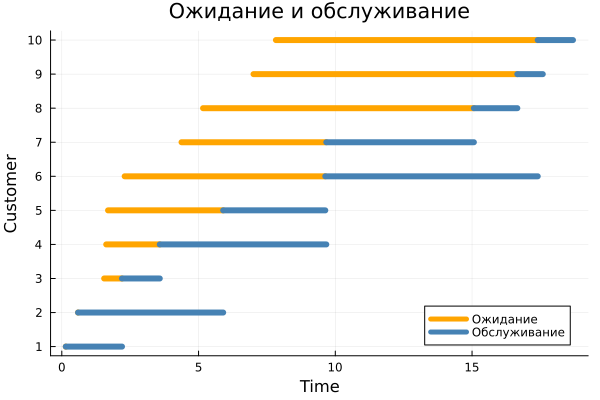

In [5]:
p1 = plot(
    xlabel = "Time",
    ylabel = "Customer",
    title = "Ожидание и обслуживание",
    yticks = 1:num_customers,
    legend = :bottomright,
)
for row in eachrow(df)
    plot!(p1, [row.arrival, row.start], [row.id, row.id], linewidth = 6, color = :orange, label = row.id == 1 ? "Ожидание" : "")
    plot!(p1, [row.start, row.finish], [row.id, row.id], linewidth = 6, color = :steelblue, label = row.id == 1 ? "Обслуживание" : "")
end
savefig(p1, plotsdir("mmc_timeline.png"))
p1

## График числа заявок в системе

Горизонтальная линия показывает число каналов: всё, что выше неё,
стоит в очереди.

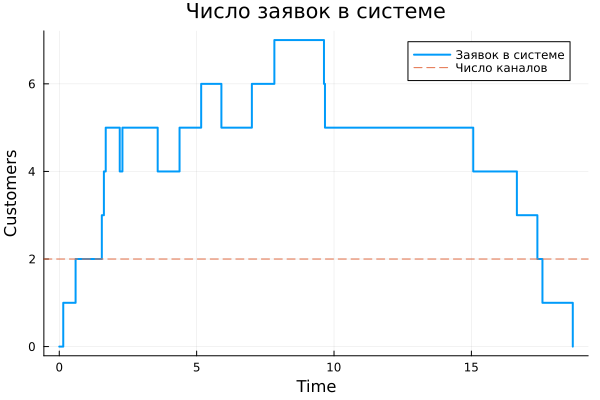

In [6]:
size_data = system_size(df)
p2 = plot(
    size_data.times,
    size_data.counts,
    seriestype = :steppost,
    linewidth = 2,
    label = "Заявок в системе",
    xlabel = "Time",
    ylabel = "Customers",
    title = "Число заявок в системе",
)
hline!(p2, [num_servers], linestyle = :dash, label = "Число каналов")
savefig(p2, plotsdir("mmc_system_size.png"))
p2

## Итог

In [7]:
println("Базовый прогон M/M/c завершён. Результаты в data/ и plots/")

Базовый прогон M/M/c завершён. Результаты в data/ и plots/
